In [13]:
import pandas as pd
df = pd.read_csv("train.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


It appears the file `train.csv` is missing, which caused the `FileNotFoundError` and subsequently the `NameError`. Assuming you're working with the Titanic dataset, I'll add a cell to download `train.csv` from a public source. If this isn't the correct dataset, please let me know.

In [14]:
import requests

# URL for the Titanic train.csv dataset (common public source)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Download the file
response = requests.get(url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Save the content to a file named 'train.csv'
with open("train.csv", "wb") as f:
    f.write(response.content)

print("train.csv downloaded successfully.")

train.csv downloaded successfully.


In [15]:
print(df.shape)

(891, 12)


In [16]:
print(df.info)

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [17]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [18]:
print(df.isnull().sum())
print(df.info)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               H

In [19]:
df = df.drop("Cabin", axis=1)
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599  71.2833        C  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0            373450   8.0500        S  


In [20]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [21]:
df["Embarked"] = df["Embarked"].fillna(df['Embarked'].mode()[0])

In [22]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**STEP 4 : INSPECT UNIQUE VALUES**

In [23]:
print(df["Sex"].unique())

print(df["Embarked"].unique())

['male' 'female']
['S' 'C' 'Q']


**STEP 5: CONVERT CATEGORICAL COLUMNS (SEX)**

In [24]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})
print(df["Sex"].head())

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64


**CONVERT CATEGORICAL COLUMNS (EMBARKED)**

In [25]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

In [28]:
print(df["Embarked"].head(10))

KeyError: 'Embarked'

In [29]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


**STEP 6 : REMOVE THE UNNECESSARY COLUMNS**

In [30]:
df = df.drop(
    ["PassengerId", "Name", "Ticket"],
    axis=1,
)

In [31]:
print(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


**Step 7: Create Features (X) and Target (y)**

In [32]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [33]:
print(X.head())

print(y.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3    0  22.0      1      0   7.2500       False        True
1       1    1  38.0      1      0  71.2833       False       False
2       3    1  26.0      0      0   7.9250       False        True
3       1    1  35.0      1      0  53.1000       False        True
4       3    0  35.0      0      0   8.0500       False        True
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


**Step 8: Train-Test Split**

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 8)
X_test: (179, 8)
y_train: (712,)
y_test: (179,)


**Step 9: Train a Decision Tree Classifier**

In [36]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

In [37]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [38]:
y_pred = dt_model.predict(X_test)

In [39]:
print("Actual Values:")
print(y_test.head(10))

print("\nPredicted Values:")
print(y_pred[:10])

Actual Values:
709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
Name: Survived, dtype: int64

Predicted Values:
[0 0 1 1 1 0 1 0 1 1]


**Step 10: Calculate Accuracy**

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7877094972067039


**Step 11: Confusion Matrix**

In [42]:
from sklearn.metrics import confusion_matrix

In [43]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[86 19]
 [19 55]]


**Step 12: Visualize Confusion Matrix**

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

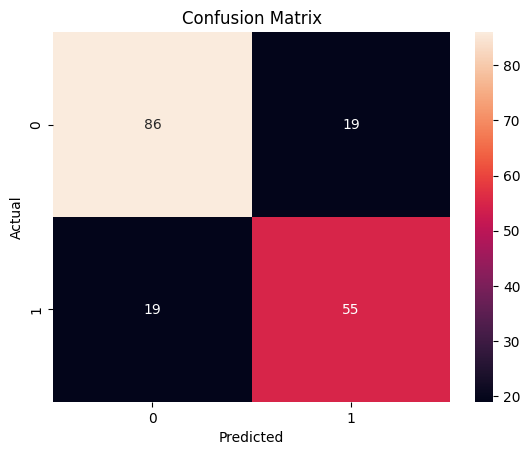

In [45]:
sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Classification Report**

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



**Random Forest**

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7988826815642458


**ROC Curve**

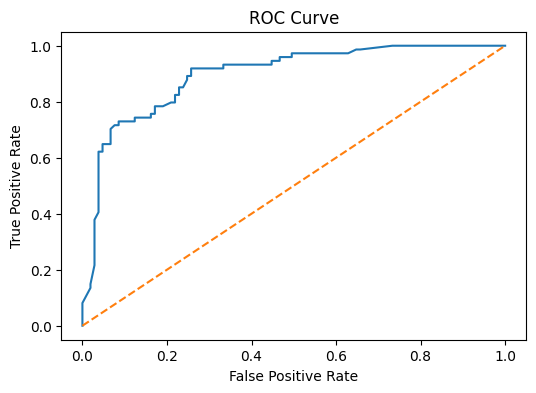

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

**AUC score**

In [50]:
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.8951093951093951
